In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

In [4]:
df=pd.read_csv('../additional_material/datasets/week11/6.3.3_spotify_5000_songs.csv')
df.head()

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


In [3]:
print(df.columns)

Index(['name                                                                                                                                                                             ',
       'artist                                          ', 'danceability ',
       'energy   ', 'key ', 'loudness ', 'mode ', 'speechiness ',
       'acousticness ', 'instrumentalness ', 'liveness ', 'valence ',
       'tempo   ', 'duration_ms ', 'time_signature ',
       'id                     ', 'html'],
      dtype='object')


In [5]:
df['name                                                                                                                                                                             '].head(5)

0    Se Eu Quiser Falar Com Deus                   ...
1    Saudade De Bahia                              ...
2    Canta Canta, Minha Gente                      ...
3    Mulher Eu Sei                                 ...
4    Rosa Morena                                   ...
Name: name                                                                                                                                                                             , dtype: object

In [5]:
# remove trailing spaces from column names
df.columns = df.columns.str.strip()
df['name'].head(5)

0    Se Eu Quiser Falar Com Deus                   ...
1    Saudade De Bahia                              ...
2    Canta Canta, Minha Gente                      ...
3    Mulher Eu Sei                                 ...
4    Rosa Morena                                   ...
Name: name, dtype: object

In [6]:
print(df.columns)

Index(['name', 'artist', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'id', 'html'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5235 entries, 0 to 5234
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              5235 non-null   object 
 1   artist            5235 non-null   object 
 2   danceability      5235 non-null   float64
 3   energy            5235 non-null   float64
 4   key               5235 non-null   int64  
 5   loudness          5235 non-null   float64
 6   mode              5235 non-null   int64  
 7   speechiness       5235 non-null   float64
 8   acousticness      5235 non-null   float64
 9   instrumentalness  5235 non-null   float64
 10  liveness          5235 non-null   float64
 11  valence           5235 non-null   float64
 12  tempo             5235 non-null   float64
 13  duration_ms       5235 non-null   int64  
 14  time_signature    5235 non-null   int64  
 15  id                5235 non-null   object 
 16  html              5235 non-null   object 


In [8]:
df.isnull().sum()

name                0
artist              0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
id                  0
html                0
dtype: int64

In [9]:
df_cluster = df.select_dtypes(include=[np.number])


In [10]:
df_cluster.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5.235000e+03,5235.000000
mean,0.509503,0.653565,5.254441,-9.338098,0.646227,0.083178,0.290043,0.257337,0.185354,0.443596,118.721407,2.479112e+05,3.902961
std,0.218041,0.288335,3.571559,6.294850,0.478185,0.071193,0.355985,0.370686,0.149410,0.277725,28.568463,1.356330e+05,0.420324
min,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.276000e+04,0.000000
25%,0.309000,0.479000,2.000000,-11.337000,0.000000,0.039000,0.002450,0.000001,0.092500,0.196000,96.174000,1.899910e+05,4.000000
50%,0.539000,0.738000,5.000000,-7.338000,1.000000,0.055800,0.095400,0.001880,0.125000,0.417000,119.180000,2.246670e+05,4.000000
75%,0.688000,0.893000,8.000000,-5.264000,1.000000,0.098650,0.565500,0.643000,0.237000,0.677000,134.019000,2.717200e+05,4.000000
max,0.967000,1.000000,11.000000,1.342000,1.000000,0.918000,0.996000,0.985000,0.987000,0.985000,213.990000,3.815787e+06,5.000000


### Scailing

In [11]:
from sklearn.preprocessing import StandardScaler
X=df_cluster.copy()
X.drop(columns=['time_signature', 'key', 'mode'], inplace=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.681116,-1.368556,-0.604187,-0.178099,1.134867,-0.694125,5.285610,-0.495488,-0.292147,0.061214
1,1.066401,-0.882963,-0.525544,-0.682409,-0.205206,-0.694278,-0.524470,0.898109,0.221160,-0.413244
2,1.566355,0.265117,-0.271661,3.706071,0.457807,-0.694112,-0.410678,1.661526,-0.875994,-0.705236
3,0.896692,-2.092782,-1.394432,-0.506814,1.654602,-0.694174,1.343056,0.289535,-0.417262,-0.454831
4,0.649009,-1.854148,-1.663249,-0.634647,1.758549,-0.693358,-0.544551,-0.149790,0.077701,0.190008


In [12]:

print(np.mean(X_scaled, axis=0))
print(np.std(X_scaled, axis=0))

[ 4.34333668e-17  1.73733467e-16 -2.82316885e-16  1.08583417e-17
  0.00000000e+00  6.51500503e-17  7.60083920e-17 -1.30300101e-16
 -2.49741859e-16  1.19441759e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Choosing K

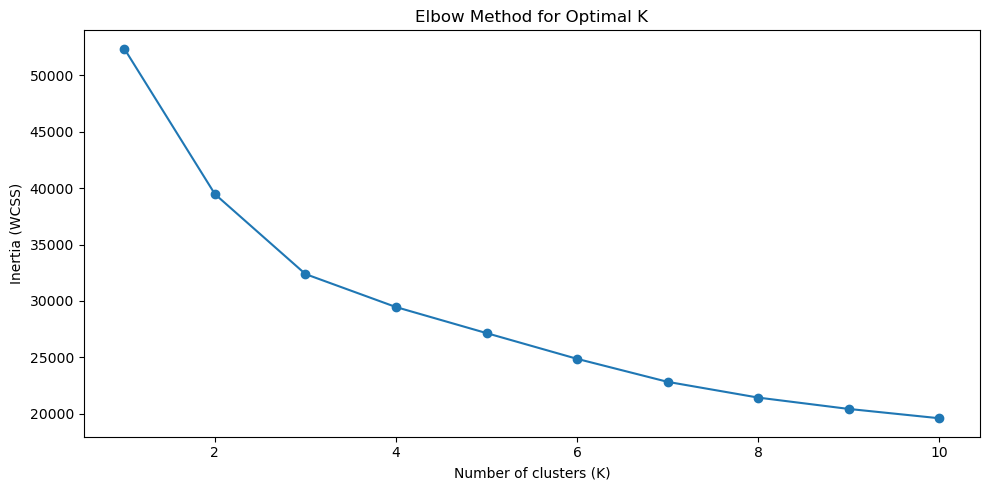

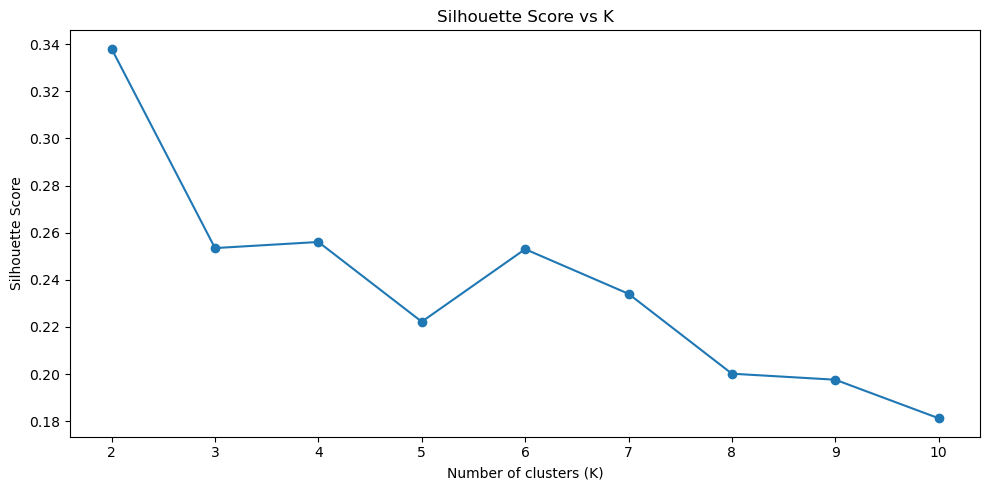

In [13]:
# Determine optimal K using Elbow Method and Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

silhouette_scores = []

for k in range(2, 11):  # silhouette requires k ≥ 2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)


# Elbow Method Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, inertias, marker='o')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow Method for Optimal K')
plt.tight_layout()
plt.show()

# Silhouette Score Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(2, 11), silhouette_scores, marker='o')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score vs K')
plt.tight_layout()
plt.show()

Big drop from K = 1 → 2 → 3 → 4

After K = 4, the curve flattens, with smaller decreases in inertia

sharp bend at K = 4.

### silhouette

### K-means with K=4

In [14]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [15]:
print(clusters)
print(type(clusters[0]))

[1 1 2 ... 0 0 0]
<class 'numpy.int32'>


In [16]:
kmeans = KMeans(
    n_clusters=4,
    init="k-means++", 
    n_init=10,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_
df["cluster"] = labels


In [17]:
distances = pd.DataFrame(index=df.index)
for i in range(k):
    diff = X_scaled - centroids[i]
    dist = np.sqrt(np.sum(diff**2, axis=1))
    distances[f"centroid_{i}"] = dist

distances.head(10)

,centroid_0,centroid_1,centroid_2,centroid_3
0,6.141167,5.870855,6.390953,6.395717
1,4.040901,1.576376,3.739663,3.854949
2,6.455128,4.553758,2.499724,5.523739
3,3.205410,3.685508,4.957344,5.177313
4,2.341316,3.558704,5.010852,4.908108
5,2.155547,3.491190,4.741932,4.410919
6,2.881927,3.257602,4.683134,4.735533
7,7.198671,6.098146,4.259053,6.287135
8,4.323909,2.020704,3.827453,3.760558
9,3.951447,1.816253,3.772207,3.109311


In [18]:
print(distances.columns)
print(df['cluster'].unique())

Index(['centroid_0', 'centroid_1', 'centroid_2', 'centroid_3'], dtype='object')
[1 2 0 3]


In [19]:
df['distance_to_centroid'] = distances.values[np.arange(len(df)), df['cluster']]

In [20]:
df.head()

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html,cluster,distance_to_centroid
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...,1,5.870855
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...,1,1.576376
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...,2,2.499724
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...,0,3.205410
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...,0,2.341316


### PCA (Principal Component Analysis)


In [21]:
from sklearn.decomposition import PCA

# Step 1: Detect and remove outliers using IQR method on distance to centroid
Q1 = df['distance_to_centroid'].quantile(0.25)
Q3 = df['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
outliers_mask = df['distance_to_centroid'] > upper_bound
X_scaled_clean = X_scaled[~outliers_mask]
df_clean = df[~outliers_mask].copy()

print(f"Original samples: {len(df)}")
print(f"Samples after removing outliers: {len(df_clean)}")
print(f"Outliers removed: {outliers_mask.sum()}")
df_clean.head()


Original samples: 5235
Samples after removing outliers: 5014
Outliers removed: 221


,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html,cluster,distance_to_centroid
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...,1,1.576376
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...,2,2.499724
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...,0,3.205410
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...,0,2.341316
5,Desafinado ...,Stan Getz,0.466,0.1460,3,-17.500,1,0.0649,0.931,0.154000,0.107,0.423,142.885,249387,4,5pstSsK0G4q86gdyy1Spqh,https://open.spotify.com/track/5pstSsK0G4q86gd...,0,2.155547


In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_clean)

# Print variance explained
print(f"\nPC1 explains {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Together: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

centroids_pca = pca.transform(centroids)



PC1 explains 0.3500 (35.00%)
PC2 explains 0.2197 (21.97%)
Together: 0.5697 (56.97%)


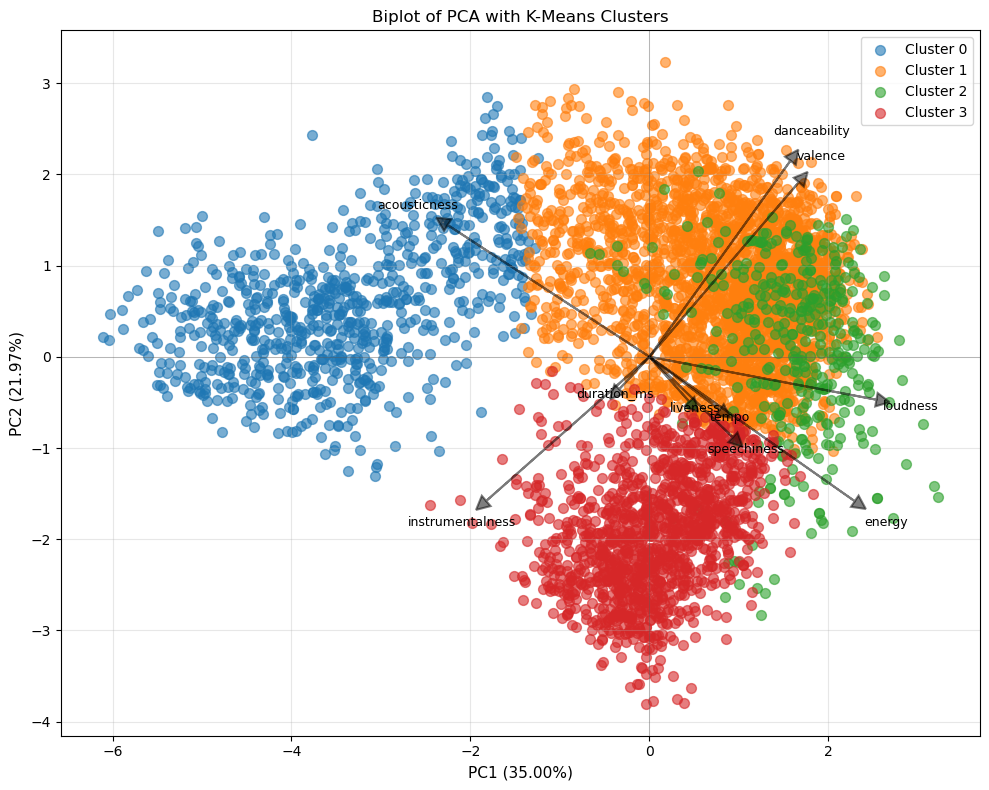

In [23]:

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

fig, ax = plt.subplots(figsize=(10, 8))

# Plot each cluster
for cluster_id in range(4):
    mask = df_clean['cluster'] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colors[cluster_id], 
               label=cluster_names[cluster_id], 
               alpha=0.6, 
               s=50)


loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
scale_factor = 3

feature_names = X.columns
for i, feature in enumerate(feature_names):
    ax.arrow(0, 0, 
             loadings[i, 0] * scale_factor, 
             loadings[i, 1] * scale_factor,
             head_width=0.15, 
             head_length=0.15, 
             fc='black', 
             ec='black',
             alpha=0.5,
             linewidth=1.5)
    ax.text(loadings[i, 0] * scale_factor * 1.15, 
            loadings[i, 1] * scale_factor * 1.15,
            feature, 
            fontsize=9, 
            ha='center', 
            va='center')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=11)
ax.set_title('Biplot of PCA with K-Means Clusters', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()


### Hierarchical Clustering Dendrogram


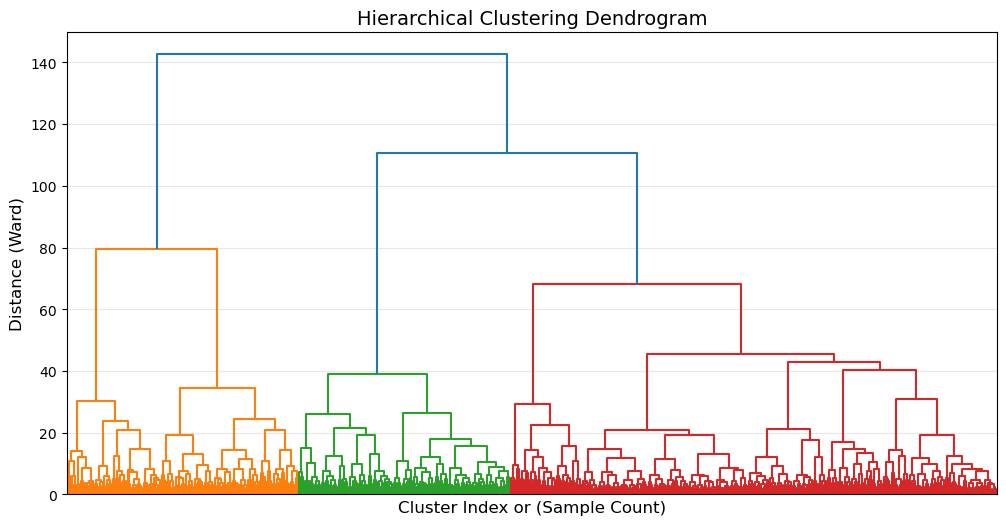

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering on cleaned data
linkage_matrix = linkage(X_scaled_clean, method='ward')

# Create the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    show_contracted=True,
    no_labels=True
)


plt.title('Hierarchical Clustering Dendrogram', fontsize=14)
plt.xlabel('Cluster Index or (Sample Count)', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.gca();


In [25]:
from scipy.cluster.hierarchy import fcluster
# Cut at distance for 4 clusters
cutting_height = 71
# Verify clusters at cutting distance
cluster_height_71 = fcluster(linkage_matrix, cutting_height, criterion='distance')
n_clusters_at_cut = len(np.unique(cluster_height_71))
print(f"Number of clusters at distance {cutting_height}: {n_clusters_at_cut}")

Number of clusters at distance 71: 4


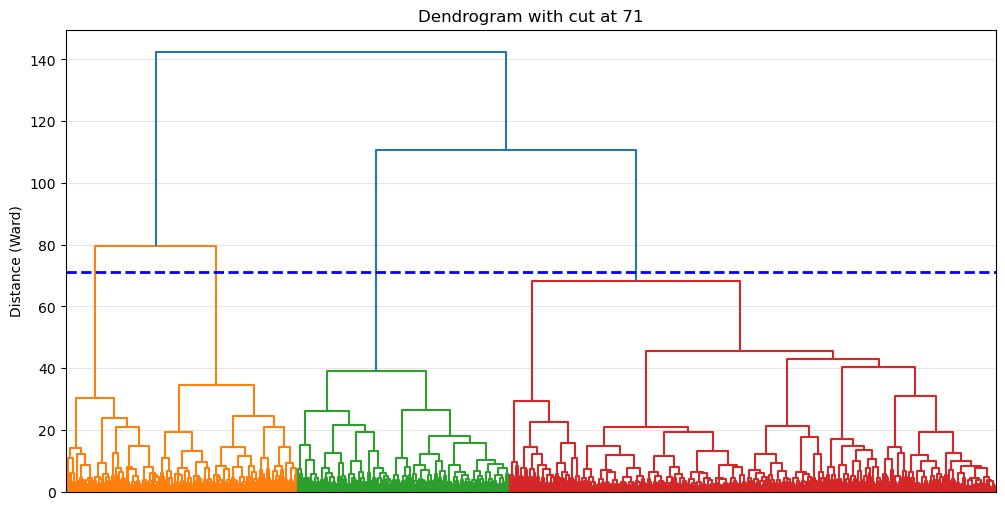

In [26]:
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, show_contracted=True, no_labels=True)
plt.axhline(y=cutting_height, color="blue", linestyle="--", linewidth=2)
plt.title("Dendrogram with cut at 71")
plt.ylabel("Distance (Ward)")
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# Create a DataFrame with hierarchical cluster assignments
df_hierarchical_71 = df_clean.copy()
df_hierarchical_71["h_cluster"] = cluster_height_71

df_hierarchical_71.head()


,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html,cluster,distance_to_centroid,h_cluster
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...,1,1.576376,2
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...,2,2.499724,4
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...,0,3.205410,2
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...,0,2.341316,2
5,Desafinado ...,Stan Getz,0.466,0.1460,3,-17.500,1,0.0649,0.931,0.154000,0.107,0.423,142.885,249387,4,5pstSsK0G4q86gdyy1Spqh,https://open.spotify.com/track/5pstSsK0G4q86gd...,0,2.155547,2


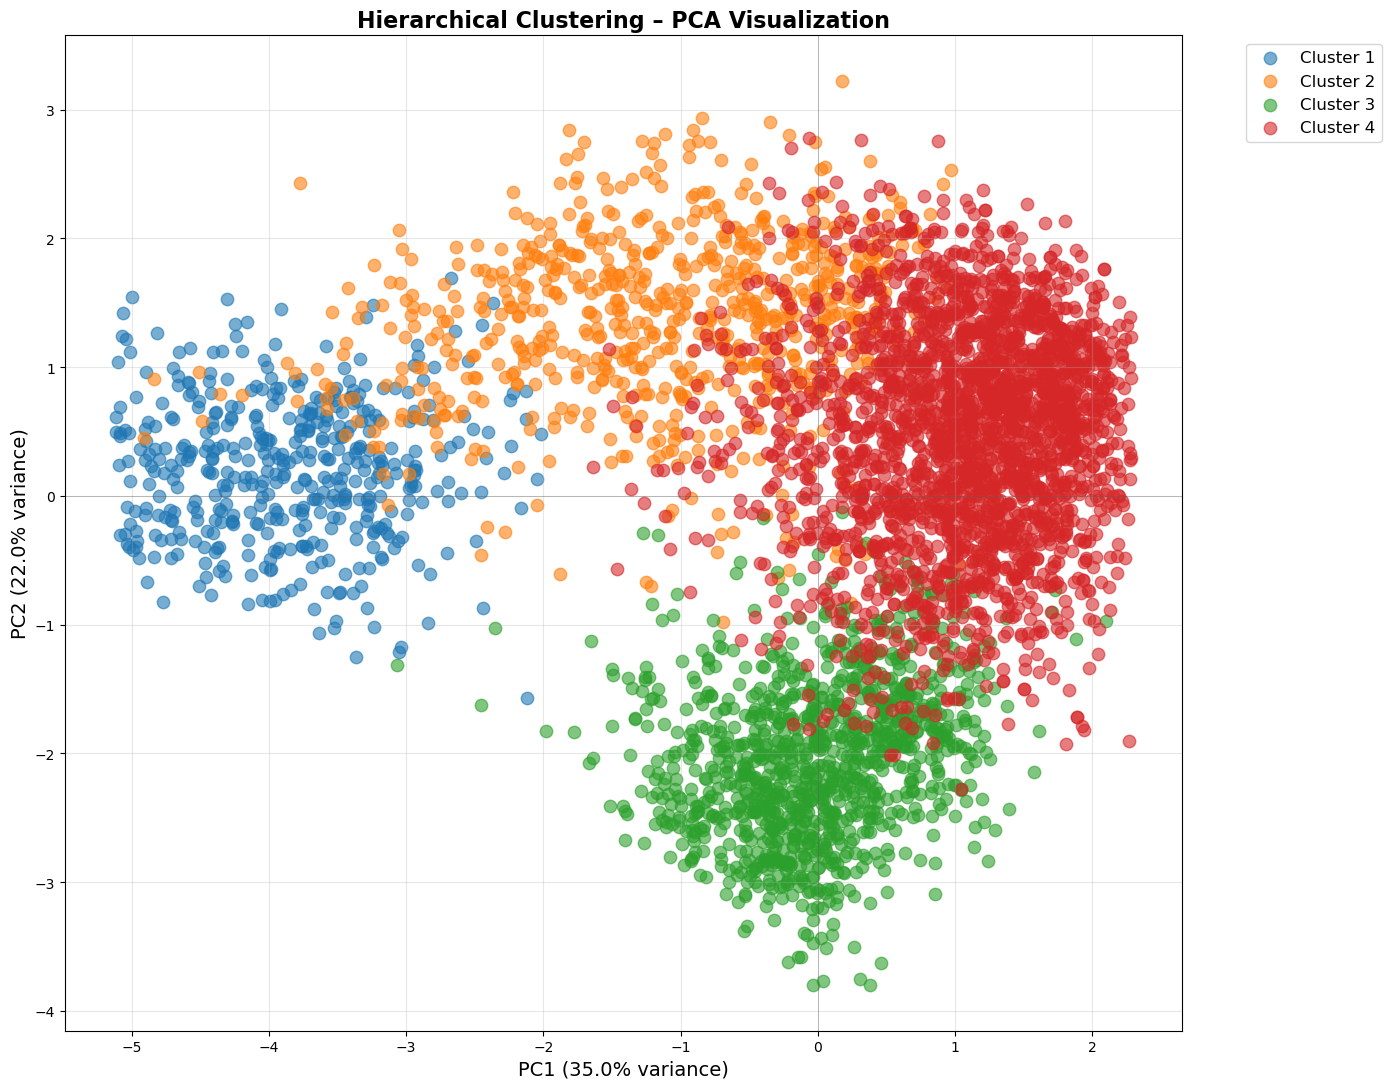

In [28]:
# Create DataFrame with PCA coordinates and hierarchical cluster assignments
X_pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df_clean.index
)

# Add hierarchical cluster assignments
X_pca_df["h_cluster"] = df_hierarchical_71["h_cluster"].astype(str)

# Trim extreme PCA outliers for visualization only
lower_q = X_pca_df["PC1"].quantile(0.01)
upper_q = X_pca_df["PC1"].quantile(0.99)

plot_df_trimmed = X_pca_df[
    (X_pca_df["PC1"] >= lower_q) &
    (X_pca_df["PC1"] <= upper_q)
].copy()

# Calculate variance explained
variance_explained = pca.explained_variance_ratio_

# Create matplotlib plot for hierarchical clusters
fig, ax = plt.subplots(figsize=(14, 11))

# Define custom colors: green, blue, orange, red
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Get unique clusters
unique_clusters = sorted(plot_df_trimmed["h_cluster"].unique())

# Plot each cluster
for idx, cluster in enumerate(unique_clusters):
    mask = plot_df_trimmed["h_cluster"] == cluster
    color = custom_colors[idx % len(custom_colors)]
    ax.scatter(
        plot_df_trimmed[mask]["PC1"],
        plot_df_trimmed[mask]["PC2"],
        c=color,
        label=f"Cluster {cluster}",
        alpha=0.6,
        s=80
    )

ax.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}% variance)', fontsize=14)
ax.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}% variance)', fontsize=14)
ax.set_title('Hierarchical Clustering – PCA Visualization', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
df_hierarchical_71['h_cluster'].value_counts()

h_cluster
4    2621
3    1143
2     741
1     509
Name: count, dtype: int64

In [30]:
# calculate the mean of each feature per cluster
df_final=df_hierarchical_71.drop(columns=['time_signature','cluster','distance_to_centroid','duration_ms'])
cluster_means = df_final.groupby('h_cluster').mean(numeric_only=True)
cluster_means

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
h_cluster,,,,,,,,,,,
1,0.314832,0.120320,5.216110,-22.005690,0.622790,0.044855,0.943530,0.844512,0.118912,0.147405,106.723181
2,0.550332,0.369297,5.128205,-12.164277,0.704453,0.046189,0.712235,0.091994,0.151296,0.489396,109.234738
3,0.261065,0.913571,5.370079,-7.929703,0.686789,0.111001,0.007707,0.554002,0.193070,0.218243,120.480075
4,0.653313,0.737755,5.243800,-6.281748,0.618466,0.086861,0.148020,0.053431,0.177238,0.594054,123.120411


In [31]:
# Calculate distance to hierarchical cluster centroid for each song
X_scaled_clean_df = pd.DataFrame(X_scaled_clean, index=df_hierarchical_71.index, columns=X.columns)

distances_to_h_centroid = []

for idx in df_hierarchical_71.index:
    # Get the hierarchical cluster ID for this song
    h_cluster_id = df_hierarchical_71.loc[idx, 'h_cluster']
    
    # Get all songs in this hierarchical cluster
    cluster_mask = df_hierarchical_71['h_cluster'] == h_cluster_id
    cluster_indices = df_hierarchical_71[cluster_mask].index
    
    # Calculate the centroid of this cluster
    X_cluster = X_scaled_clean_df.loc[cluster_indices].values
    cluster_centroid = X_cluster.mean(axis=0)
    
    # Calculate distance from this song to the cluster centroid
    song_features = X_scaled_clean_df.loc[idx].values
    distance = np.sqrt(np.sum((song_features - cluster_centroid)**2))
    
    distances_to_h_centroid.append(distance)

# Add the distance column to df_hierarchical_71
df_hierarchical_71['distance_to_h_centroid'] = distances_to_h_centroid

# Recreate df_final with the new distance column
df_final = df_hierarchical_71.drop(columns=['time_signature','cluster','duration_ms'])

print("Distance to hierarchical cluster centroid calculated!")
print(df_final[['name', 'h_cluster', 'distance_to_h_centroid']].head(10))

Distance to hierarchical cluster centroid calculated!
                                                 name  h_cluster  \
1   Saudade De Bahia                              ...          2   
2   Canta Canta, Minha Gente                      ...          4   
3   Mulher Eu Sei                                 ...          2   
4   Rosa Morena                                   ...          2   
5   Desafinado                                    ...          2   
6   Madalena                                      ...          2   
8   Brigas Nunca Mais                             ...          4   
9   Previsao                                      ...          2   
10  The Girl From Ipanema                         ...          2   
11  Blue Bossa - Remastered                       ...          2   

    distance_to_h_centroid  
1                 1.966008  
2                 4.269388  
3                 2.354837  
4                 1.810027  
5                 1.865900  
6                 1.821

In [32]:
#Get first 5 songs from cluster 1 with complete links
pd.set_option('display.max_colwidth', None)
df_final[df_final['h_cluster'] == 1][['name', 'html']].sample(5)

,name,html
4509,A Meaningful Moment Through a Meaning(less) Process,https://open.spotify.com/track/4TrCvd1PrqI14lZb7tEtYo
2558,I'm A Fool To Want You,https://open.spotify.com/track/3kYrQXSao9IXp3EzMZQt5J
4570,Introspection,https://open.spotify.com/track/2dUStnVW2074l0kDgyaOXi
2000,"Liebestraum, S. 541, No. 3",https://open.spotify.com/track/0peVXz7bx2tRYiehqdv4Ge
1926,Challen,https://open.spotify.com/track/2z9c6wYSWk3Q2foQP5C49D


In [33]:
#Get first 5 songs from cluster 1 with complete links
pd.set_option('display.max_colwidth', None)
df_final[df_final['h_cluster'] == 2][['name', 'html']].sample(5)

,name,html
145,Catendé - Live,https://open.spotify.com/track/5u16KY1xdK7fz9ZZJt0vEx
1072,Walk on By,https://open.spotify.com/track/3xsOtNxtBW0oTI1OWKAzTm
2451,This Is Always,https://open.spotify.com/track/6Kr25pa3pTd4no3yA0EcW1
488,Dona Ocell,https://open.spotify.com/track/1unwCjn9z9fs9DTnaySuNi
2406,"Giordano: Andrea Chénier, Act 3: ""La mamma morta"" (Maddalena)",https://open.spotify.com/track/36soyVMvHB2FRb0DgLr9ll


In [40]:
# Get top 5 songs nearest to hierarchical cluster centroid for each cluster 
pd.set_option('display.max_colwidth', None)

for cluster_id in sorted(df_final['h_cluster'].unique()):
    # Get all songs in this cluster
    cluster_songs = df_final[df_final['h_cluster'] == cluster_id]
    
    # Sort by distance_to_h_centroid and get top 5 nearest
    top_5_nearest = cluster_songs.nsmallest(5, 'distance_to_h_centroid')
    
    # Display results
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} - Top 5 Songs Nearest to Centroid")
    print(f"{'='*80}")
    result = top_5_nearest[['name', 'html', 'distance_to_h_centroid']].copy()
    #to csv
    result.to_csv(f'top_5_nearest_cluster_{cluster_id}.csv', index=False)
    print(result.to_string())
    print()


CLUSTER 1 - Top 5 Songs Nearest to Centroid
                                                                                                                                                                                   name                                                   html  distance_to_h_centroid
1954  Before You Go - Piano Version                                                                                                                                                      https://open.spotify.com/track/5HOLJ0YEEXbsYBZAetdWie                0.429680
1942  La Mer                                                                                                                                                                             https://open.spotify.com/track/6iOMES4Hz0Xf7ExmyCGf5D                0.693798
1995    Liebestraum No. 3 in A-Flat Major, S. 541/3                                                                                                                   

In [39]:
top_5_nearest

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,id,html,distance_to_centroid,h_cluster,distance_to_h_centroid
4836,Wovon sollen wir träumen,Frida Gold,0.685,0.727,7,-5.756,1,0.0554,0.00074,0.000112,0.2020,0.586,127.995,5xkhzuMwzoWhYXQyQp1h1y,https://open.spotify.com/track/5xkhzuMwzoWhYXQyQp1h1y,0.804907,4,0.694561
4868,Liebe ist meine Rebellion,Frida Gold,0.645,0.777,0,-3.365,0,0.0781,0.00988,0.000024,0.2070,0.564,127.993,0jMRc5KoWu26Uf8NmqWSjS,https://open.spotify.com/track/0jMRc5KoWu26Uf8NmqWSjS,1.049307,4,0.723265
2950,Something Just Like This - Don Diablo Remix,The Chainsmokers,0.720,0.746,11,-5.567,0,0.0983,0.12500,0.000476,0.0929,0.511,124.039,15MTd64KUMG7CF6mOyovsQ,https://open.spotify.com/track/15MTd64KUMG7CF6mOyovsQ,1.079401,4,0.754545
1760,New Rules,Dua Lipa,0.762,0.700,9,-6.021,0,0.0694,0.00261,0.000016,0.1530,0.608,116.073,2ekn2ttSfGqwhhate0LSR0,https://open.spotify.com/track/2ekn2ttSfGqwhhate0LSR0,0.928462,4,0.785369
621,All Day And Night,Jax Jones,0.585,0.782,1,-4.101,0,0.0897,0.26900,0.000000,0.1560,0.521,121.908,33CfD8UkDEcSdAP9j4QpUY,https://open.spotify.com/track/33CfD8UkDEcSdAP9j4QpUY,0.965922,4,0.796369


In [36]:
# now add links
df_copy = df_final[['name', 'html', 'h_cluster', 'distance_to_h_centroid']].copy()
df_copy.to_csv('spotify_clustered_songs.csv', index=False)

In [37]:
df_copy

,name,html,h_cluster,distance_to_h_centroid
1,Saudade De Bahia,https://open.spotify.com/track/5QGM1U0eCYrQuwSJwTm5Zq,2,1.966008
2,"Canta Canta, Minha Gente",https://open.spotify.com/track/0NLIFSZxPzQhCwnkn5PJYs,4,4.269388
3,Mulher Eu Sei,https://open.spotify.com/track/3mXqOdlLE1k67WsAxryPFs,2,2.354837
4,Rosa Morena,https://open.spotify.com/track/7bSzjzjTkWT2CkIPPdp0eA,2,1.810027
5,Desafinado,https://open.spotify.com/track/5pstSsK0G4q86gdyy1Spqh,2,1.865900
...,...,...,...,...
5225,"Symphony No. 3 - ""Chant de la nuit"", Op. 27: Largo...",https://open.spotify.com/track/6VZ0CYMRhrdprO6u9rMwxC,1,3.570719
5226,"Pines Of Rome, P. 141: 3. The Pines Of The Janiculum",https://open.spotify.com/track/09R0O5z1MZR7s2vbNlDKTG,1,2.080123
5227,"Don Giovanni, K.527: Overture",https://open.spotify.com/track/02GgkjgUsnDcgQCL0JQfG3,1,1.784249
5228,"Music for Strings, Percussion and Celesta, BB 114: II. Allegro",https://open.spotify.com/track/67nERYyvMwe3dUQZXpUvDo,1,1.974360


In [38]:
# now separate by h_cluster and save to separate csv files and remove name, distance_to_h_centroid
for cluster_id in sorted(df_final['h_cluster'].unique()):
    cluster_songs = df_final[df_final['h_cluster'] == cluster_id]
    cluster_songs_subset = cluster_songs[['name', 'html']]
    filename = f'Aspotify_cluster_{cluster_id}_songs.csv'
    cluster_songs_subset.to_csv(filename, index=False)
    print(f"Saved {len(cluster_songs_subset)} songs to {filename}")


Saved 509 songs to Aspotify_cluster_1_songs.csv
Saved 741 songs to Aspotify_cluster_2_songs.csv
Saved 1143 songs to Aspotify_cluster_3_songs.csv
Saved 2621 songs to Aspotify_cluster_4_songs.csv
